# AquaFix Chatbot: Training Report

This notebook builds, trains, evaluates and exports the AI behind the AquaFix website chatbot.

**Approach: a hybrid assistant**

| Part | Type | Job |
|---|---|---|
| Intent classifier | Neural network trained here (PyTorch) | Understands what the customer is asking (29 intents) |
| Pool calculator | Rule-based expert system (`assets/js/chatbot/pool-calculator.js`) | Sizes filter, pump and accessories from the pool dimensions |
| Response layer | Hand-written answers (`chatbot/data/intents.json`) | Gives correct, business-approved answers |

The classifier is trained in Python, then its weights are exported to JSON and run in the browser with plain JavaScript,
so the chatbot works on a static website (GitHub Pages) with no server and no paid API.

**Pipeline:** dataset → features → augmentation → baseline → neural network → cross-validation → confidence threshold → final model → test set → export.

In [1]:
import json, random
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import aquabot as ab

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
ab.set_seed(SEED)
print("PyTorch", torch.__version__)

PyTorch 2.14.0+cpu


## 1. Dataset

The dataset was written by hand for AquaFix. Each **intent** is one thing a customer can ask
(opening hours, green pool, pump sizing...). Each intent has example sentences (**patterns**) and the answers the bot gives.

A separate **test set** (`test_set.json`) was written afterwards with different wording and some typos. It is never used for training
or for choosing settings, so it measures how the bot behaves with real customers.

Intents: 29
Training sentences: 600
Held-out test sentences: 148


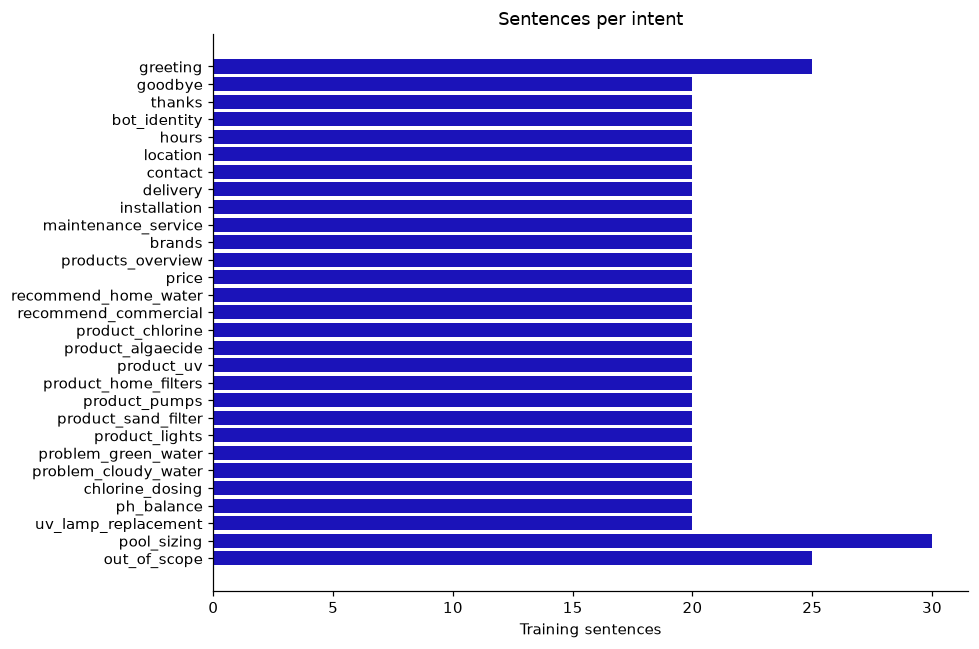

In [2]:
intents = ab.load_intents()
texts, tags = ab.patterns_and_labels(intents)
labels = [i["tag"] for i in intents]
label_index = {l: i for i, l in enumerate(labels)}
y = np.array([label_index[t] for t in tags])

test_texts, test_tags = ab.load_test_set()
y_test = np.array([label_index[t] for t in test_tags])

print(f"Intents: {len(labels)}")
print(f"Training sentences: {len(texts)}")
print(f"Held-out test sentences: {len(test_texts)}")

counts = Counter(tags)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels[::-1], [counts[l] for l in labels[::-1]], color="#1b13b9")
ax.set_xlabel("Training sentences")
ax.set_title("Sentences per intent")
plt.tight_layout(); plt.show()

## 2. Turning text into numbers (features)

A neural network needs numbers. Each message becomes a list of **features**:

* `w:` words (`w:chlorine`)
* `b:` word pairs, to keep a bit of word order (`b:pool_is`)
* `c:` character trigrams (`c:chl`, `c:hlo`...), so a typo like *chlorin* still matches *chlorine*

Numbers are replaced by `num`, so *"my pool is 8 by 4"* and *"my pool is 12 by 6"* look the same to the model.
The message becomes a vector with one position per known feature (1 if present, 0 if not), normalized to length 1.

In [3]:
example = "My pool is 8x4, what pump do I need?"
print("Tokens:  ", ab.tokenize(example))
feats = sorted(ab.extract_features(example))
print(f"Features ({len(feats)}):", feats[:12], "...")

Tokens:   ['my', 'pool', 'is', 'num', 'x', 'num', 'what', 'pump', 'do', 'i', 'need']
Features (47): ['b:do_i', 'b:i_need', 'b:is_num', 'b:my_pool', 'b:num_what', 'b:num_x', 'b:pool_is', 'b:pump_do', 'b:what_pump', 'b:x_num', 'c:<do', 'c:<i>'] ...


## 3. Data augmentation

With only ~20 sentences per intent, the model would memorize them. **Augmentation** creates 4 noisy copies of every training sentence:
a keyboard typo, a dropped word, or a filler like *"please"* / *"can you tell me"*. This teaches the model to ignore small mistakes.
Augmentation is only applied to training data, never to validation or test data.

In [4]:
rng = random.Random(1)
for s in ["how much chlorine do i need", "my pool is green", "do you deliver to beirut"]:
    print(f"{s!r:32} ->", [ab.augment(s, rng) for _ in range(3)])

'how much chlorine do i need'    -> ['how much chlorine do i nneed', 'how much chlorinr do i need', 'how mucj chlorine do i need']
'my pool is green'               -> ['my pool is green please', 'hey my pool is green', 'my pool is rgeen']
'do you deliver to beirut'       -> ['do you delver to beirut', 'do you deliver to beirut pls', 'do you deliver to beirut pls']


## 4. Baseline: logistic regression

Before the neural network, a simple linear model gives a reference score. We use **5-fold cross-validation**:
the training sentences are split into 5 parts; each part is used once for validation while the model trains on the other 4.
This gives a fair estimate even with a small dataset.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
texts_arr = np.array(texts, dtype=object)

def cross_validate(fit_predict, augment=True):
    """Returns out-of-fold probabilities for every training sentence.
    Augmentation happens inside each fold, after the split, so no noisy copy of a
    validation sentence can leak into training."""
    oof = np.zeros((len(texts), len(labels)))
    for fold, (tr, va) in enumerate(skf.split(texts, y)):
        tr_x, tr_y = list(texts_arr[tr]), [tags[i] for i in tr]
        oof[va] = fit_predict(tr_x, tr_y, list(texts_arr[va]), augment, fold)
    return oof

def to_xy(x, t, vocab):
    return ab.vectorize(x, vocab), np.array([label_index[s] for s in t])

def logreg(tr_x, tr_y, va_x, augment, fold):
    vocab = ab.build_vocab(tr_x)
    if augment:
        tr_x, tr_y = ab.augment_dataset(tr_x, tr_y, seed=fold)
    clf = LogisticRegression(C=10, max_iter=2000).fit(*to_xy(tr_x, tr_y, vocab))
    probs = np.zeros((len(va_x), len(labels)))
    probs[:, clf.classes_] = clf.predict_proba(ab.vectorize(va_x, vocab))
    return probs

oof_lr = cross_validate(logreg)
print(f"Logistic regression, 5-fold CV accuracy: {accuracy_score(y, oof_lr.argmax(1)):.1%}")

Logistic regression, 5-fold CV accuracy: 71.3%


## 5. Neural network

Architecture (`IntentNet` in `aquabot.py`):

```
input features (~2,100) -> Dense 32 + ReLU -> Dropout 40% -> Dense 29 -> softmax
```

* **Loss:** cross-entropy with label smoothing (0.05)
* **Optimizer:** AdamW, learning rate 0.001, weight decay 0.0001, batches of 64
* **Early stopping:** stop when validation loss has not improved for 40 epochs and keep the best epoch
* **Vocabulary:** built from the original sentences only (not the noisy copies)

*How these settings were chosen:* we compared vocabularies built from original vs augmented text, and 32 vs 64 hidden units,
with 5-fold cross-validation. All scored within about 2 points of each other, so we picked the **smallest** model:
it downloads fastest on the website. The test set was not used for this choice.

First, one training run with an 80/20 split to look at the learning curves.

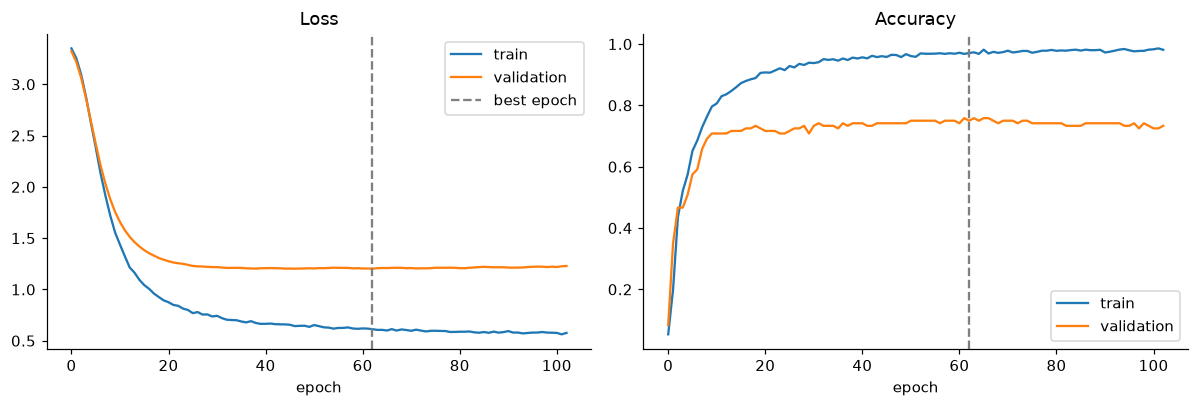

Vocabulary: 2070 features | best epoch: 63


In [6]:
tr_x, va_x, tr_y, va_y = train_test_split(texts, tags, test_size=0.2, stratify=tags, random_state=SEED)
aug_x, aug_y = ab.augment_dataset(tr_x, tr_y)
vocab = ab.build_vocab(tr_x)
model, hist = ab.train_model(
    ab.vectorize(aug_x, vocab), np.array([label_index[t] for t in aug_y]), len(labels),
    ab.vectorize(va_x, vocab), np.array([label_index[t] for t in va_y]),
    lr=1e-3, epochs=300, patience=40)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(hist["train_loss"], label="train"); a1.plot(hist["val_loss"], label="validation")
a1.axvline(hist["best_epoch"] - 1, ls="--", c="gray", label="best epoch"); a1.set_title("Loss"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(hist["train_acc"], label="train"); a2.plot(hist["val_acc"], label="validation")
a2.axvline(hist["best_epoch"] - 1, ls="--", c="gray"); a2.set_title("Accuracy"); a2.set_xlabel("epoch"); a2.legend()
plt.tight_layout(); plt.show()
print(f"Vocabulary: {len(vocab)} features | best epoch: {hist['best_epoch']}")

Now the same 5-fold cross-validation as the baseline, plus an **ablation**: the same network trained **without** augmentation,
to measure how much augmentation helps.

Logistic regression (augmented)    71.3%
Neural network, no augmentation    68.2%
Neural network (augmented)         70.2%


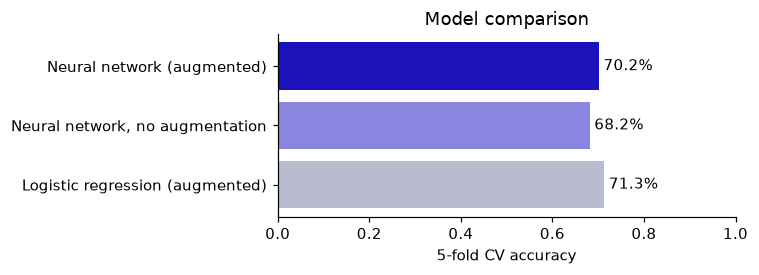

Epochs for the final model (median best epoch): 33


In [7]:
best_epochs = []
def neural_net(tr_x, tr_y, va_x, augment, fold):
    # hold out 15% of the fold's original sentences for early stopping, then augment the rest
    a, b, ya, yb = train_test_split(tr_x, tr_y, test_size=0.15, stratify=tr_y, random_state=fold)
    vocab = ab.build_vocab(a)
    if augment:
        a, ya = ab.augment_dataset(a, ya, seed=fold)
    m, h = ab.train_model(*to_xy(a, ya, vocab), len(labels), *to_xy(b, yb, vocab),
                          lr=1e-3, epochs=400, patience=40)
    best_epochs.append(h["best_epoch"])
    return ab.predict_proba(m, ab.vectorize(va_x, vocab))

oof_nn = cross_validate(neural_net, augment=True)
nn_epochs = list(best_epochs)
oof_nn_noaug = cross_validate(neural_net, augment=False)

results = {
    "Logistic regression (augmented)": accuracy_score(y, oof_lr.argmax(1)),
    "Neural network, no augmentation": accuracy_score(y, oof_nn_noaug.argmax(1)),
    "Neural network (augmented)": accuracy_score(y, oof_nn.argmax(1)),
}
for name, acc in results.items():
    print(f"{name:34} {acc:.1%}")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(list(results), list(results.values()), color=["#b9bccf", "#8a86e0", "#1b13b9"])
ax.set_xlim(0, 1); ax.set_xlabel("5-fold CV accuracy"); ax.set_title("Model comparison")
for i, v in enumerate(results.values()):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center")
plt.tight_layout(); plt.show()
FINAL_EPOCHS = int(np.median(nn_epochs))
print("Epochs for the final model (median best epoch):", FINAL_EPOCHS)

## 6. Confidence threshold ("I don't understand")

The softmax output is a probability for each intent. When the highest probability is low, the bot should say it did not understand
instead of giving a wrong answer. We choose the threshold on the **cross-validation** predictions (not the test set),
maximizing *correct answers minus wrong answers*: a wrong answer is worse than asking the customer to rephrase.

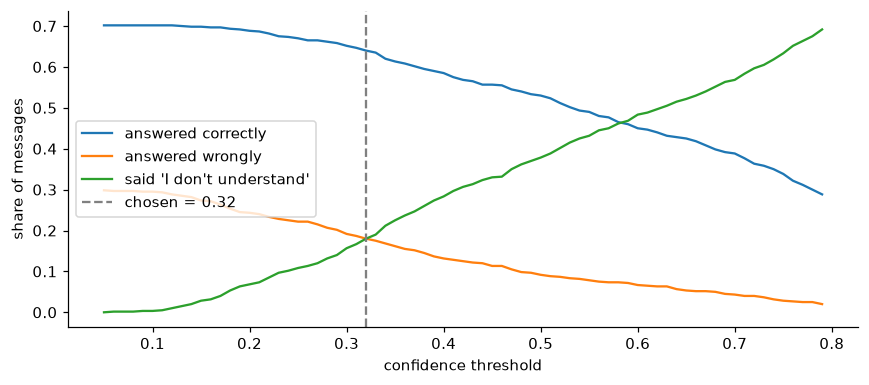

Threshold: 0.32


In [8]:
conf, pred = oof_nn.max(1), oof_nn.argmax(1)
thresholds = np.round(np.arange(0.05, 0.8, 0.01), 2)
correct = np.array([((conf >= t) & (pred == y)).mean() for t in thresholds])
wrong = np.array([((conf >= t) & (pred != y)).mean() for t in thresholds])
score = correct - wrong
THRESHOLD = float(thresholds[score.argmax()])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(thresholds, correct, label="answered correctly")
ax.plot(thresholds, wrong, label="answered wrongly")
ax.plot(thresholds, 1 - correct - wrong, label="said 'I don't understand'")
ax.axvline(THRESHOLD, ls="--", c="gray", label=f"chosen = {THRESHOLD}")
ax.set_xlabel("confidence threshold"); ax.set_ylabel("share of messages"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Threshold: {THRESHOLD}")

## 7. Final model and held-out test

The final model is trained on **all** training sentences (augmented) for the number of epochs found by cross-validation,
then evaluated once on the held-out test set.

In [9]:
all_x, all_y = ab.augment_dataset(texts, tags)
final_vocab = ab.build_vocab(texts)
final_model, _ = ab.train_model(
    ab.vectorize(all_x, final_vocab), np.array([label_index[t] for t in all_y]), len(labels),
    lr=1e-3, epochs=FINAL_EPOCHS)

test_probs = ab.predict_proba(final_model, ab.vectorize(test_texts, final_vocab))
test_pred, test_conf = test_probs.argmax(1), test_probs.max(1)
accepted = test_conf >= THRESHOLD

print(f"Test accuracy (top prediction):          {accuracy_score(y_test, test_pred):.1%}")
print(f"Answered with confidence >= threshold:   {accepted.mean():.1%} of messages")
print(f"Accuracy of the answers it gave:         {(test_pred[accepted] == y_test[accepted]).mean():.1%}")
print()
print(classification_report(y_test, test_pred, labels=range(len(labels)), target_names=labels, zero_division=0))

Test accuracy (top prediction):          95.9%
Answered with confidence >= threshold:   97.3% of messages
Accuracy of the answers it gave:         97.2%

                      precision    recall  f1-score   support

            greeting       1.00      1.00      1.00         5
             goodbye       1.00      1.00      1.00         5
              thanks       1.00      1.00      1.00         5
        bot_identity       0.83      1.00      0.91         5
               hours       0.83      1.00      0.91         5
            location       0.83      1.00      0.91         5
             contact       1.00      0.60      0.75         5
            delivery       1.00      0.80      0.89         5
        installation       1.00      1.00      1.00         5
 maintenance_service       1.00      0.80      0.89         5
              brands       1.00      1.00      1.00         5
   products_overview       1.00      1.00      1.00         5
               price       0.83      1.

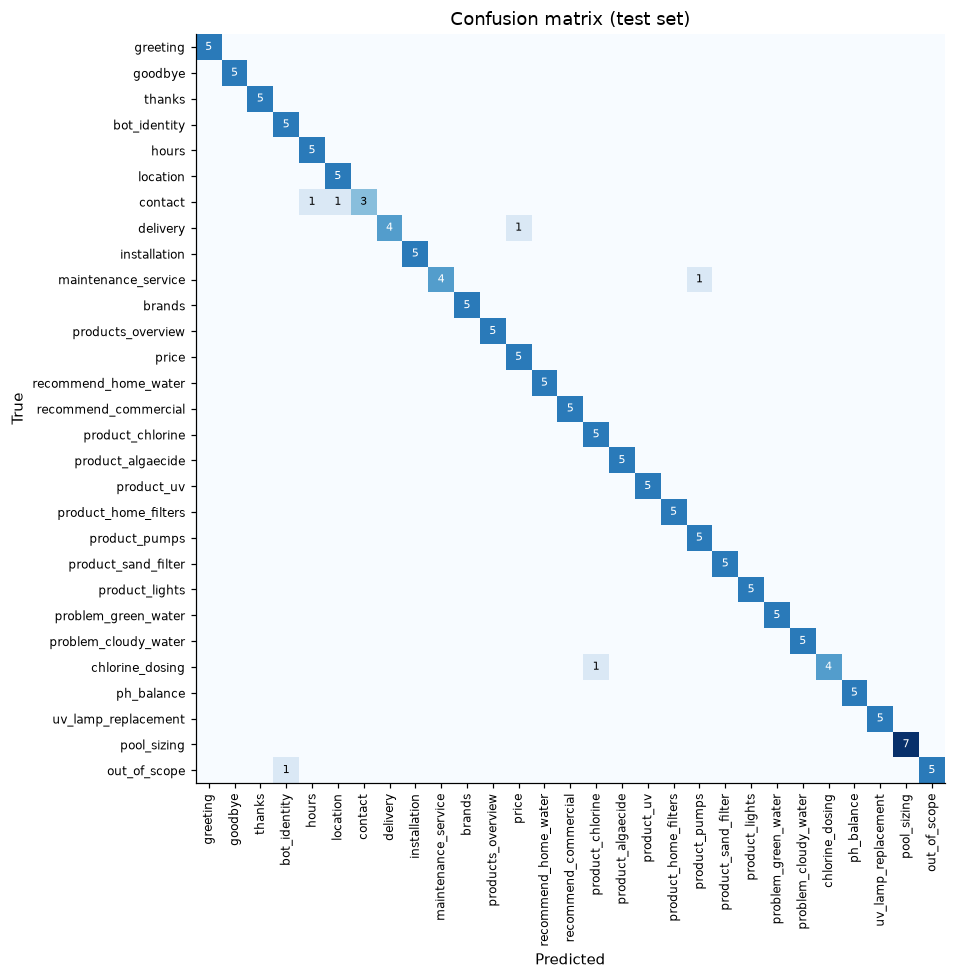

In [10]:
cm = confusion_matrix(y_test, test_pred, labels=range(len(labels)))
fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if cm[i, j] > 3 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()

In [11]:
print("Mistakes on the test set:")
for t, true, p, c in zip(test_texts, y_test, test_pred, test_conf):
    if true != p:
        flag = "rejected (below threshold)" if c < THRESHOLD else "WRONG ANSWER"
        print(f"  {t!r:45} true={labels[true]:22} pred={labels[p]:22} conf={c:.2f}  {flag}")

Mistakes on the test set:
  'i want to call the shop'                     true=contact                pred=hours                  conf=0.19  rejected (below threshold)
  'can i get your whatsap'                      true=contact                pred=location               conf=0.37  WRONG ANSWER
  'how much does shipping cost'                 true=delivery               pred=price                  conf=0.88  WRONG ANSWER
  'pump makes a loud noise'                     true=maintenance_service    pred=product_pumps          conf=0.34  WRONG ANSWER
  'chlorine grams per m3'                       true=chlorine_dosing        pred=product_chlorine       conf=0.50  WRONG ANSWER
  'how do i make a cake'                        true=out_of_scope           pred=bot_identity           conf=0.17  rejected (below threshold)


### Robustness to typos

Customers type fast on phones. We add one random keyboard typo to every long word of the test sentences and compare
a model trained **with** augmentation against the same model trained **without** it.

Example: what time do you guys open -> wjat timee do you guy oepn


without augmentation   clean test: 87.8%   test with typos: 78.4%
with augmentation      clean test: 95.9%   test with typos: 87.2%


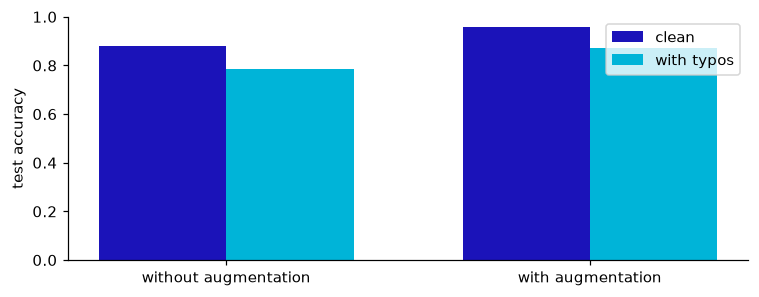

In [12]:
typo_rng = random.Random(7)
typo_texts = [" ".join(ab._typo(w, typo_rng) if len(w) >= 4 else w for w in t.split()) for t in test_texts]
print("Example:", test_texts[20], "->", typo_texts[20])

plain_model, _ = ab.train_model(*to_xy(texts, tags, final_vocab), len(labels), lr=1e-3, epochs=FINAL_EPOCHS)
rows = {}
for name, m in [("without augmentation", plain_model), ("with augmentation", final_model)]:
    clean = accuracy_score(y_test, ab.predict_proba(m, ab.vectorize(test_texts, final_vocab)).argmax(1))
    noisy = accuracy_score(y_test, ab.predict_proba(m, ab.vectorize(typo_texts, final_vocab)).argmax(1))
    rows[name] = (clean, noisy)
    print(f"{name:22} clean test: {clean:.1%}   test with typos: {noisy:.1%}")

fig, ax = plt.subplots(figsize=(7, 2.8))
w = 0.35
for k, (name, (c, n)) in enumerate(rows.items()):
    ax.bar([k - w / 2], [c], w, color="#1b13b9", label="clean" if k == 0 else None)
    ax.bar([k + w / 2], [n], w, color="#00b4d8", label="with typos" if k == 0 else None)
ax.set_xticks(range(len(rows)), list(rows)); ax.set_ylim(0, 1); ax.set_ylabel("test accuracy"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Try it

Messages with typos and different wording than the training data:

In [13]:
def ask(msg):
    p = ab.predict_proba(final_model, ab.vectorize([msg], final_vocab))[0]
    i = p.argmax()
    tag = labels[i] if p[i] >= THRESHOLD else "(not sure, asks to rephrase)"
    print(f"{msg!r:45} -> {tag:28} {p[i]:.2f}")

for msg in ["wat time do u open", "my pool went green help", "pump for a 10 by 5 pool",
            "do you sell chlorne", "is there delivery to tripoli", "who won the world cup"]:
    ask(msg)

'wat time do u open'                          -> hours                        0.98
'my pool went green help'                     -> problem_green_water          0.64
'pump for a 10 by 5 pool'                     -> pool_sizing                  0.84
'do you sell chlorne'                         -> (not sure, asks to rephrase) 0.23
'is there delivery to tripoli'                -> delivery                     0.98
'who won the world cup'                       -> out_of_scope                 0.87


## 9. Export for the website

* `assets/chatbot/model.json`: vocabulary, labels, threshold and weights (read by `assets/js/chatbot/intent-model.js`)
* `assets/chatbot/responses.json`: answers, quick replies and actions for each intent
* `chatbot/tests/fixtures/parity.json`: Python predictions for the test sentences. A Node test checks that the JavaScript
  implementation gives the same probabilities, which proves the browser runs exactly the trained model.

**Quantization:** weights are stored as 8-bit integers (int8) with one scale per matrix instead of 32-bit floats.
The file becomes 4 times smaller, so the chatbot loads fast on phones. We check that accuracy does not drop.

In [14]:
q_model = ab.quantized_copy(final_model)
q_probs = ab.predict_proba(q_model, ab.vectorize(test_texts, final_vocab))
print(f"Test accuracy float32: {accuracy_score(y_test, test_pred):.1%}")
print(f"Test accuracy int8:    {accuracy_score(y_test, q_probs.argmax(1)):.1%}")
print(f"Max probability change: {np.abs(q_probs - test_probs).max():.4f}")

model_path = ab.export_model(final_model, final_vocab, labels, THRESHOLD)
resp_path = ab.export_responses(intents)

parity = {"texts": test_texts, "probs": np.round(q_probs, 5).tolist()}
parity_path = ab.ROOT / "chatbot" / "tests" / "fixtures" / "parity.json"
parity_path.parent.mkdir(parents=True, exist_ok=True)
parity_path.write_text(json.dumps(parity), encoding="utf8")

n_params = sum(p.numel() for p in final_model.parameters())
print(f"Parameters: {n_params:,}")
print(f"{model_path.name}: {model_path.stat().st_size / 1024:.0f} KB")
print(f"{resp_path.name}: {resp_path.stat().st_size / 1024:.1f} KB")

Test accuracy float32: 95.9%
Test accuracy int8:    95.9%
Max probability change: 0.0057
Parameters: 76,541
model.json: 128 KB
responses.json: 9.2 KB


## 10. Pool sizing rules (expert system)

When the classifier detects `pool_sizing` (or `chlorine_dosing`), the bot asks for the pool size and runs these rules
(`assets/js/chatbot/pool-calculator.js`, covered by unit tests in `chatbot/tests/`):

| Item | Rule |
|---|---|
| Volume | length × width × average depth (round: π × r² × depth) |
| Flow rate | volume ÷ 6 h turnover (all water filtered every 6 hours) |
| Sand filter | smallest filter whose capacity at ~50 m³/h per m² is ≥ flow rate (400 to 900 mm) |
| Filter sand | typical amount for that filter size |
| Pump | smallest pump (0.5 to 3 HP) that delivers the flow at ~10 m head |
| Skimmers | 1 per 25 m² of surface |
| Return inlets | 1 per 20 m², minimum 2 |
| Main drains | 2 (anti-entrapment safety) |
| LED lights | 1 per 20 m² |
| Vacuum hose | longest side + depth + 1 m, rounded up to a standard length |
| Start-up chlorine | 1.8 g SDIC per m³ per ppm, to reach 3 ppm |

Pools needing more than ~31 m³/h are flagged as commercial projects for the AquaFix team.

## 11. Limitations and future work

* The dataset is small and written by one person; real customer messages collected from the website would improve it most.
* English only. Arabic, French and Lebanese Arabizi could be added with more training sentences in those languages.
* The bot does not remember context beyond the pool sizing step.
* Sizing rules are estimates; final equipment choice should be confirmed by an AquaFix technician.